In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from torch import nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from PIL import Image
import torch.optim as optim
import torch as t 

Using huggingface dataset since the dataset link on University of California, Berkeley is broken.

In [6]:
%%capture
from datasets import load_dataset

In [8]:
train_dataset = load_dataset("zh-plus/tiny-imagenet", split="train")
valid_dataset = load_dataset("zh-plus/tiny-imagenet", split="valid")

In [9]:
train_subset = train_dataset.shuffle(seed=43).select(range(100))
valid_subset = valid_dataset.shuffle(seed=42).select(range(100))

In [10]:
train_images = [i["image"].convert("L") for i in train_subset]
valid_images = [i["image"].convert("L") for i in valid_subset]

In [11]:
transform = transforms.Compose([
    transforms.ToTensor()
])

# we use torch.stack to turn a python list of tensors to a tensor
train_images_tensor = t.stack([transform(image) for image in train_images])
valid_images_tensor = t.stack([transform(image) for image in valid_images])

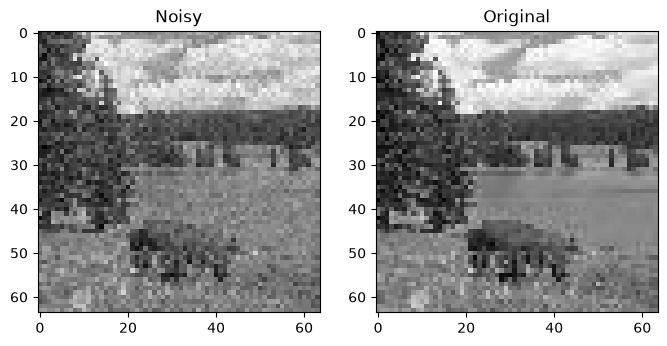

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(8, 8))
ax[0].imshow(train_images_tensor[0].squeeze(0) + t.normal(mean=0, std=0.05, size=(64, 64)), cmap="gray")
ax[0].set_title('Noisy')
ax[1].imshow(train_images_tensor[0].squeeze(0), cmap="gray")
ax[1].set_title('Original')
plt.show()

AS it seems from the images, Gaussian noise with mean of 0 and standard deviation of 0.2 seems like a good choice for noise. So the noisy images will be constructed in the cell below.

In [13]:
train_noise = t.normal(mean=0, std=0.05, size=(100, 1, 64, 64))
valid_noise = t.normal(mean=0, std=0.05, size=(100, 1, 64, 64))

train_images_tensor_noisy = train_images_tensor + train_noise
valid_images_tensor_noisy = valid_images_tensor + valid_noise

Constructing AutoEncoder

In [14]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3)
        self.bn3 = nn.BatchNorm2d(16)
        self.conv4 = nn.Conv2d(in_channels=16, out_channels=4, kernel_size=3)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        return F.relu(self.conv4(x))


In [15]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.convT1 = nn.ConvTranspose2d(in_channels=4, out_channels=16, kernel_size=3)
        self.bn1 = nn.BatchNorm2d(16)
        self.convT3 = nn.ConvTranspose2d(in_channels=16, out_channels=16, kernel_size=3)
        self.bn3 = nn.BatchNorm2d(16)
        self.convT4 = nn.ConvTranspose2d(in_channels=16, out_channels=1, kernel_size=3)
        # self.bn4 = nn.BatchNorm2d(1)
    def forward(self, x):
        x = F.relu(self.bn1(self.convT1(x)))
        # x = F.relu(self.bn2(self.convT2(x)))
        x = F.relu(self.bn3(self.convT3(x)))
        return F.relu(self.convT4(x))

In [16]:
class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        encoded = self.encoder(x)
        reconstructed = self.decoder(encoded)
        return reconstructed

In [17]:
epochs = 200
batch_size=20

# TorchDataset will pair each original image with its noisy version
train_tensor_pairs = TensorDataset(train_images_tensor, train_images_tensor_noisy)
valid_tensor_pairs = TensorDataset(valid_images_tensor, valid_images_tensor_noisy)

# DataLoader will be used for batching and shuffling during training the Neural Network
data_loader = DataLoader(train_tensor_pairs, batch_size=batch_size, shuffle=True)

Training Step

In [22]:
# AE instantiation
model = AE()

# Loss function
criterion = nn.MSELoss()

# Optimizer setup
optimizer = optim.Adam(model.parameters(), lr=1.e-3)

train_losses = []
valid_losses = []

start_idx = 0
step = len(valid_tensor_pairs) // epochs

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for targets, inputs in data_loader:
        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # average epoch loss by dividing total loss by the number of batches per epoch
    average_loss = total_loss / len(data_loader)
    train_losses.append(average_loss)


    # Validation
    model.eval()

    # if epoch + 1 == epochs:
    #     valid_targets = valid_tensor_pairs[start_idx:][0]
    #     valid_inputs = valid_tensor_pairs[start_idx:][1]

    # else:
    #     valid_targets = valid_tensor_pairs[start_idx:start_idx+step][0]
    #     valid_inputs = valid_tensor_pairs[start_idx:start_idx+step][1]
    #     start_idx += step


    # we want consistent input for validation evaluation
    valid_targets = valid_tensor_pairs[:][0]
    valid_inputs = valid_tensor_pairs[:][1]

    with t.no_grad():
        valid_outputs = model(valid_inputs)

    valid_loss = criterion(valid_outputs, valid_targets)

    
    valid_losses.append(valid_loss.item())

    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"Epoch{epoch + 1}: Average training batch loss = {average_loss}")

Epoch1: Average training batch loss = 1.0266292572021485
Epoch10: Average training batch loss = 0.05924105793237686
Epoch20: Average training batch loss = 0.03834212049841881
Epoch30: Average training batch loss = 0.02825862169265747
Epoch40: Average training batch loss = 0.022755338251590727
Epoch50: Average training batch loss = 0.020164383947849272
Epoch60: Average training batch loss = 0.018537735752761363
Epoch70: Average training batch loss = 0.0180815152823925
Epoch80: Average training batch loss = 0.016280865110456944
Epoch90: Average training batch loss = 0.015656876750290392
Epoch100: Average training batch loss = 0.014845089614391327
Epoch110: Average training batch loss = 0.014401060342788697
Epoch120: Average training batch loss = 0.016050989925861358
Epoch130: Average training batch loss = 0.01321527510881424
Epoch140: Average training batch loss = 0.014145381934940814
Epoch150: Average training batch loss = 0.014553369954228401
Epoch160: Average training batch loss = 0.0

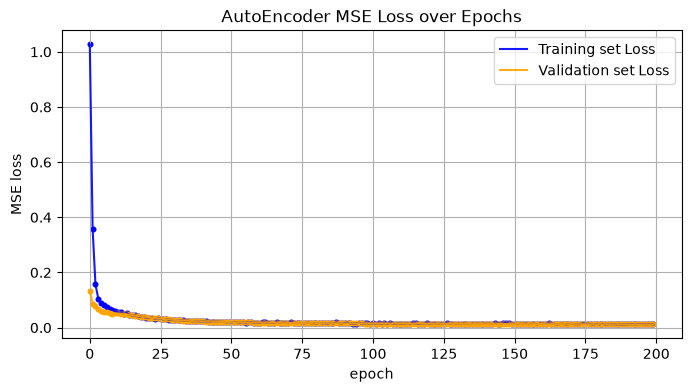

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(train_losses, color='blue', label='Training set Loss', alpha=0.9)
ax.scatter(range(epochs), train_losses, c='blue', s=11)
ax.plot(valid_losses, color='orange', label='Validation set Loss', alpha=0.9)
ax.scatter(range(epochs), valid_losses, c='orange', s=11)
ax.set_xlabel('epoch')
ax.set_ylabel('MSE loss')
ax.legend()
ax.set_title("AutoEncoder MSE Loss over Epochs")
# ax.set_xticks(range(epochs))
ax.grid()

Visual plot to display Autoencoder's performance

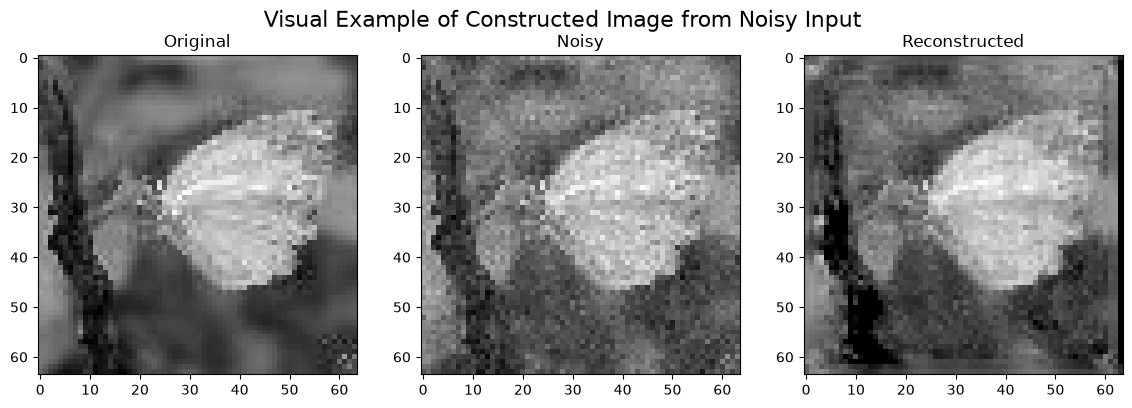

In [24]:
# random_idx = np.random.randint(0, len(valid_tensor_pairs))
random_idx=30

random_input = valid_tensor_pairs[random_idx][1]
random_target = valid_tensor_pairs[random_idx][0]

model.eval()
random_output = model(random_input.unsqueeze(0))
fig, ax = plt.subplots(1, 3, figsize=(14, 10))
ax[0].imshow(random_target.squeeze(0).squeeze(0).detach().numpy(), cmap="gray")
ax[1].imshow(random_input.squeeze(0).squeeze(0).detach().numpy(), cmap="gray")
ax[2].imshow(random_output.squeeze(0).squeeze(0).detach().numpy(), cmap="gray")
ax[0].set_title('Original')
ax[1].set_title('Noisy')
ax[2].set_title('Reconstructed')
fig.suptitle("Visual Example of Constructed Image from Noisy Input", fontsize=16, y=0.7)
plt.show()